# Narragansett Bay SFINCS Tutorial

This notebook demonstrates how to build and run a
[SFINCS](https://sfincs.readthedocs.io) coastal flood model for
Narragansett Bay, Rhode Island using the `coastal_calibration` Python API.

Unlike the Lavaca Bay example, this model includes **NWM river
discharge** forcing in addition to STOFS ocean boundary conditions,
precipitation, wind, and barometric pressure.

The workflow has three phases:

1. **Create** — build a SFINCS model from an Area of Interest (AOI)
   polygon using HydroMT-SFINCS.  This produces the grid, elevation,
   subgrid tables, boundary conditions, and discharge source points.
2. **Run** — execute the full simulation pipeline: download forcing
   data, write SFINCS input files, run the model, produce a
   downscaled flood depth map, and compare results against NOAA
   tide-gauge observations.
3. **Visualize** — plot the flood depth map and station comparisons.

## Setup

In [ ]:
from __future__ import annotations

import os
from pathlib import Path

notebook_dir = Path.cwd()  # assumes notebook is run from docs/examples/notebooks/
os.chdir(notebook_dir.parent / "narragansett-ri")

## 1. Create the SFINCS model

### Build the create configuration

`SfincsCreateConfig.from_dict` accepts a plain dictionary with the same
structure as the YAML file.

In [ ]:
from coastal_calibration import SfincsCreateConfig, SfincsCreator, configure_logger

configure_logger(level="INFO")

create_config = SfincsCreateConfig.from_dict(
    {
        "aoi": "./aoi.geojson",
        "output_dir": "./output",
        "download_dir": "../downloads/narragansett_grid",
        "grid": {
            "resolution": 512,
            "crs": "utm",
            "rotated": False,
            "refinement": [
                {"polygon": "./aoi.geojson", "level": 3, "buffer_m": -200},
            ],
        },
        "elevation": {
            "datasets": [
                {
                    "name": "nws_30m",
                    "zmin": -20000,
                    "source": "nws_30m",
                    "coastal_domain": "atlgulf",
                },
                {"name": "gebco_15arcs", "zmin": -20000, "source": "gebco_15arcs"},
            ],
            "buffer_cells": 1,
        },
        "mask": {"zmin": -50.0, "boundary_zmax": -1.0, "reset_bounds": True},
        "subgrid": {
            "nr_subgrid_pixels": 4,
            "lulc_dataset": "esa_worldcover",
            "manning_land": 0.04,
            "manning_sea": 0.02,
        },
        "nwm_discharge": {
            "flowlines": "./discharge_nwm.geojson",
            "nwm_id_column": "flowpath_id",
        },
        "add_noaa_gages": True,
    }
)

### Run the create workflow

In [ ]:
creator = SfincsCreator(create_config)
result = creator.run()
if not result.success:
    raise RuntimeError(f"Model creation failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    
Start Time: 2026-03-13 10:58:03                                                 
----------------------------------------                                        
Stage: create_grid                                                              
Start Time: 2026-03-13 10:58:03                                                 
  Create SFINCS grid from AOI                                                   
  AOI:                                                                          
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/narragansett-ri/aoi.geojson 
  Resolution: 512 m, CRS: utm                                                   
  Refinement: 1 polygon(s), max level 3                                         
  Grid created successfully                                                     
  [✓] COMPLETED (4s)                                                            
----------------------------

WorkflowResult: SUCCESS
  Start:     2026-03-13 10:58:03
  End:       2026-03-13 10:59:15
  Duration:  1m 12s
  Completed: create_grid, create_fetch_data, create_elevation, create_mask, create_boundary, create_discharge, create_subgrid, create_obs, create_write


### Inspect the created model

In [ ]:
output = Path("output")
assert output.exists(), (
    f"Output directory not found: {output.resolve()} — run the create step first."
)

for f in sorted(output.iterdir()):
    if f.name.startswith(".") or f.suffix == ".log":
        continue
    size = f.stat().st_size
    label = f"{size / 1e6:.1f} MB" if size > 1e6 else f"{size / 1e3:.1f} KB"
    print(f"  {f.name:<30s} {label}")

  create_progress.json           2.2 KB
  create_result.json             1.3 KB
  gis                            0.1 KB
  obs_station_map.json           0.5 KB
  sfincs.inp                     0.9 KB
  sfincs.nc                      60.8 MB
  sfincs.obs                     0.2 KB
  sfincs_nwm.src                 0.2 KB
  sfincs_subgrid.nc              92.1 MB
  subgrid                        0.2 KB


## 2. Run the simulation pipeline

### Build the run configuration

`CoastalCalibConfig.from_dict` accepts the same dictionary structure as
the run YAML file.

In [ ]:
from coastal_calibration import CoastalCalibConfig, CoastalCalibRunner

run_config = CoastalCalibConfig.from_dict(
    {
        "model": "sfincs",
        "simulation": {
            "start_date": "2024-01-09",
            "duration_hours": 60,
            "coastal_domain": "atlgulf",
            "meteo_source": "nwm_ana",
        },
        "boundary": {"source": "stofs"},
        "paths": {
            "work_dir": "./run",
            "raw_download_dir": "../downloads",
        },
        "download": {"enabled": True},
        "model_config": {
            "prebuilt_dir": "./output",
            "discharge_locations_file": "./output/sfincs_nwm.src",
            "merge_discharge": True,
            "forcing_to_mesh_offset_m": 0.0,  # STOFS already in NAVD88
            "vdatum_mesh_to_msl_m": 0.1,  # NAVD88 mesh -> MSL
            "include_precip": True,
            "include_wind": True,
            "include_pressure": True,
            # Flood depth map — reuse the NWS 30 m DEM fetched during model creation.
            "floodmap_dem": "../downloads/narragansett_grid/nws_30m.tif",
            "inp_overrides": {
                "tspinup": 10800,
            },
        },
    }
)

### Note on the SFINCS executable

The `sfincs_exe` field overrides the default PATH lookup for the SFINCS binary.
When running inside a pixi environment with the `sfincs` feature, the binary
is compiled automatically and available on PATH — no `sfincs_exe` needed.

If you compiled SFINCS manually, set `sfincs_exe` to the path of the binary.
If neither is available, the pipeline will complete all stages up to
`sfincs_run` and then fail at model execution.

### Run the pipeline

In [ ]:
runner = CoastalCalibRunner(run_config)
result = runner.run()
if not result.success:
    raise RuntimeError(f"Model run failed at stage '{result.stages_failed}': {result.errors}")
print(result)

Coastal Calibration Workflow                                                    
Start Time: 2026-03-13 10:59:15                                                 
----------------------------------------                                        
Stage: download                                                                 
Start Time: 2026-03-13 10:59:15                                                 
  Download input data (NWM, STOFS)                                              
  meteo/nwm_ana: 61/61 [OK]                                                     
  hydro/nwm: 61/61 [OK]                                                         
  coastal/stofs: 1/1 [OK]                                                       
  Total: 123/123 (failed: 0)                                                    
  Download complete — raw files stored in                                       
/Users/tchegini/repos/nwm-coastal-dev/docs/examples/downloads                   
  [✓] COMPLETED (7s)        

WorkflowResult: SUCCESS
  Start:     2026-03-13 10:59:15
  End:       2026-03-13 11:11:03
  Duration:  11m 47s
  Completed: download, sfincs_symlinks, sfincs_data_catalog, sfincs_init, sfincs_timing, sfincs_forcing, sfincs_discharge, sfincs_precip, sfincs_wind, sfincs_pressure, sfincs_write, sfincs_run, sfincs_floodmap, sfincs_plot


## 3. View results

The pipeline generates station comparison plots (modelled vs. observed
water levels at NOAA CO-OPS tide gauges).

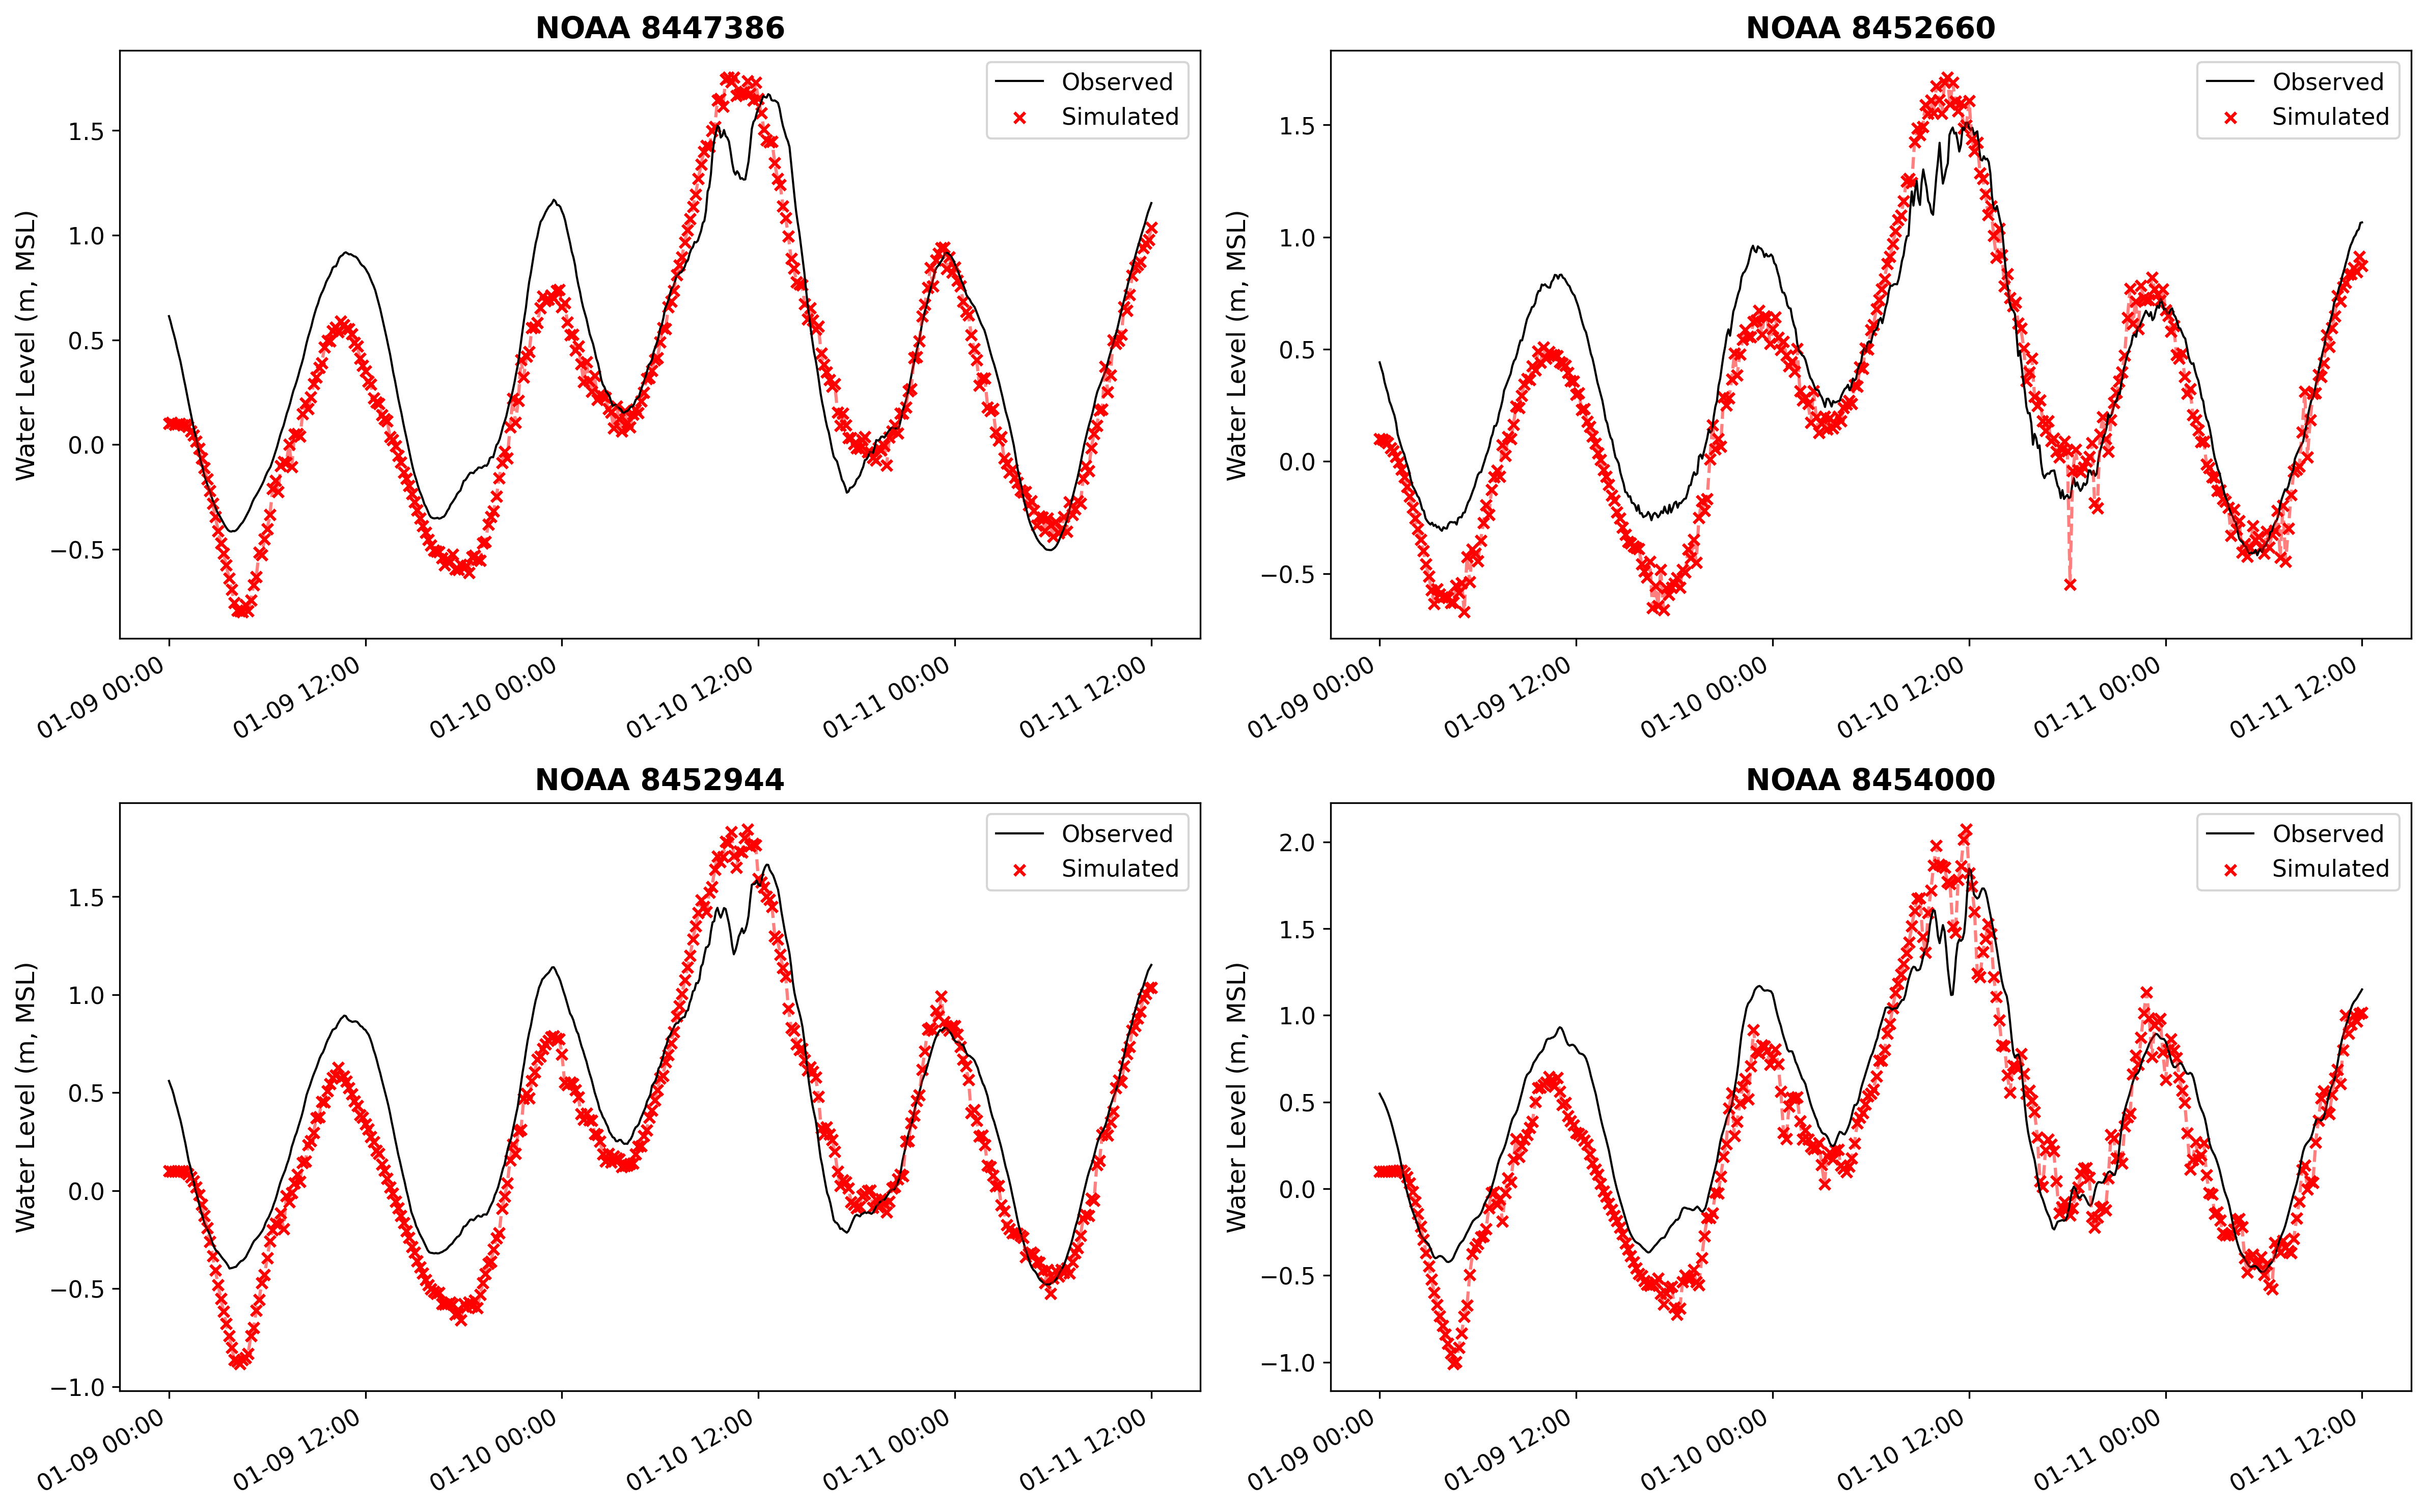

In [ ]:
from IPython.display import Image, display

figs_dir = Path("run/sfincs_model/figs")
assert figs_dir.exists(), f"Results not found: {figs_dir.resolve()} — run the pipeline first."

for png in sorted(figs_dir.glob("stations_comparison_*.png")):
    display(Image(filename=str(png), width=800))

## 4. SFINCS mesh

The SFINCS model uses a quadtree grid.  Coarser cells (512 m) cover
the offshore domain while regions near the coastline and inside the
bay are at the base resolution.  When no refinement is applied the
grid is a single-level regular mesh.

In [ ]:
from coastal_calibration.plotting import SfincsGridInfo, plot_floodmap, plot_mesh

info = SfincsGridInfo.from_model_root("run/sfincs_model")
print(info)

SfincsGridInfo(quadtree, EPSG:32619)
  Faces:        283,608
  Edges:        569,283
  Level 1:        3,269 cells (512 m)
  Level 2:        1,267 cells (256 m)
  Level 3:        2,704 cells (128 m)
  Level 4:      276,368 cells (64 m)


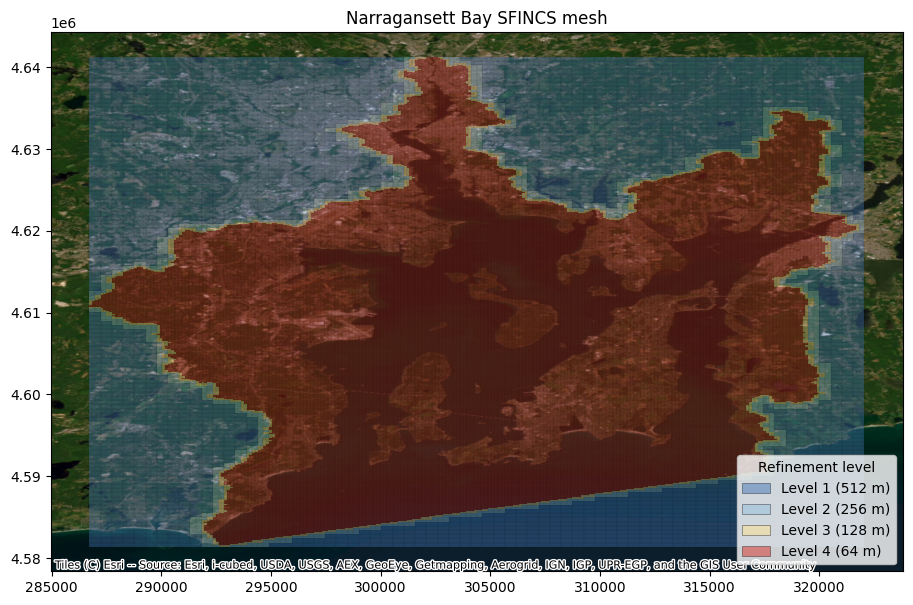

In [ ]:
fig, ax = plot_mesh(info, title="Narragansett Bay SFINCS mesh")

## 5. Flood depth map

The pipeline automatically produces a downscaled flood depth map when
`floodmap_dem` is configured.  The `sfincs_floodmap` stage reads the
maximum water surface elevation (`zsmax`) from the SFINCS map output,
builds an index COG mapping DEM pixels to SFINCS grid cells, and
writes a Cloud Optimized GeoTIFF of flood depth at the DEM resolution.

  CRS:          EPSG:4269
  Size:         467 x 601
  Resolution:   0.0009 x 0.0009 deg
  File size:    0.4 MB
  Display size: 234 x 301 (overview 2x)
  Valid pixels: 28,416 / 70,434 (40.3%)
  Depth range:  0.05 – 59.93 m


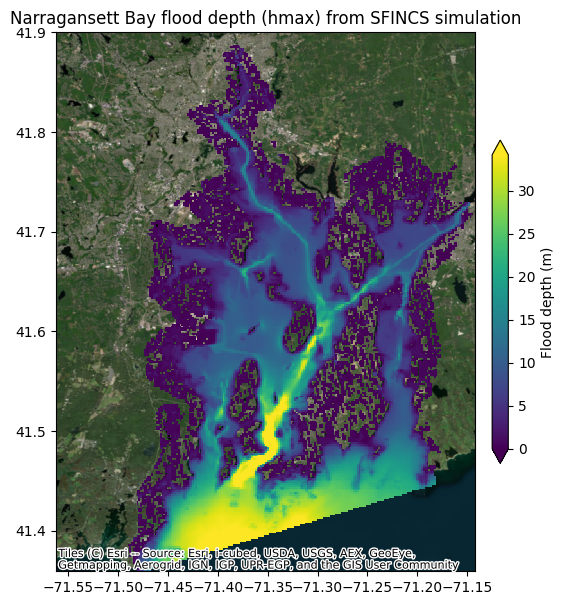

In [ ]:
fig, ax = plot_floodmap(
    "run/sfincs_model/floodmap_hmax.tif",
    title="Narragansett Bay flood depth (hmax) from SFINCS simulation",
)
fig.savefig("../images/narragansett_thumb.png", dpi=150, bbox_inches="tight")

The flood depth COG can be opened in QGIS or any GIS viewer.
You can also generate a flood depth map outside the pipeline
using the standalone function:

```python
from coastal_calibration.utils.floodmap import create_flood_depth_map

create_flood_depth_map(
    model_root="run/sfincs_model",
    dem_path="../downloads/narragansett_grid/nws_30m.tif",
)
```

## Summary

This notebook demonstrated the full Narragansett Bay SFINCS workflow
via the Python API:

1. `SfincsCreateConfig.from_dict({...})` + `SfincsCreator(config).run()`
   — built the model from an AOI with NWM discharge source points
2. `CoastalCalibConfig.from_dict({...})` + `CoastalCalibRunner(config).run()`
   — downloaded data, ran SFINCS with compound forcing (ocean + river +
   meteo), and compared results against NOAA observations
3. Inspected the quadtree mesh and its refinement levels
4. Visualized the downscaled flood depth map (`floodmap_hmax.tif`)